# Передбачення успішності фільмів - ML аналіз

## Бізнес-питання
**Чи можна передбачити успішність фільму ДО його випуску?**

### Мета проекту:
1. Визначити критерії "успішного фільму" на основі даних
2. Створити ML моделі для передбачення успіху
3. Зрозуміти які фактори найбільше впливають на успіх
4. Надати рекомендації для інвесторів та продюсерів

### Підходи до визначення успіху:
- **Комерційний успіх**: Високі касові збори (проксі: numVotes)
- **Критичний успіх**: Високий рейтинг (averageRating)
- **Блокбастер**: Комбінація обох + масова аудиторія
- **Overperformer**: Кращий результат ніж очікується для жанру/бюджету

### ML підходи:
- **Класифікація**: Хіт vs Не-хіт (Binary/Multi-class)
- **Регресія**: Точне передбачення рейтингу/популярності
- **Feature Importance**: Що найважливіше для успіху?


## 1. Ініціалізація та завантаження даних


In [1]:
import sys
sys.path.append('/app')

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator, RegressionEvaluator
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ініціалізація Spark
spark = SparkSession.builder \
    .appName("FilmSuccessPrediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

print("✅ Spark сесія створена")
print(f"Версія Spark: {spark.version}")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/03 01:40:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/03 01:40:59 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


✅ Spark сесія створена
Версія Spark: 4.0.1


In [2]:
# Завантаження даних
from utils.reader import read_data

dataframes = read_data(spark)

print("✅ Дані завантажено:")
for name, df in dataframes.items():
    print(f"  - {name}: {df.count():,} записів")


✅ Дані завантажено:


  - name.basics: 14,861,451 записів


  - title.akas: 53,898,347 записів


  - title.basics: 12,048,919 записів


  - title.crew: 12,048,919 записів


  - title.episode: 9,285,221 записів


  - title.principals: 95,709,663 записів
  - title.ratings: 1,634,695 записів


## 2. Підготовка даних для аналізу

Об'єднаємо дані з різних таблиць щоб отримати повну картину кожного фільму


In [3]:
# Базовий датасет: тільки фільми з рейтингами
movies = dataframes["title.basics"].filter(
    F.col("titleType") == "movie"
).join(
    dataframes["title.ratings"],
    "tconst"
).filter(
    (F.col("numVotes") >= 100) &  # Мінімум 100 голосів для достовірності
    (F.col("startYear").isNotNull()) &
    (F.col("startYear") >= 1980) &  # Фокус на сучасне кіно
    (F.col("startYear") <= 2023)
)

print(f"✅ Базовий датасет: {movies.count():,} фільмів (1980-2023, ≥100 votes)")

# Додаємо додаткові фічі
movies = movies.withColumn(
    "numGenres", 
    F.size(F.split(F.col("genres"), ","))
).withColumn(
    "isRecent",
    F.when(F.col("startYear") >= 2015, 1).otherwise(0)
).withColumn(
    "decade",
    (F.floor(F.col("startYear") / 10) * 10).cast("integer")
)

# Показуємо приклад
movies.select(
    "tconst", "primaryTitle", "startYear", "genres", "numGenres",
    "runtimeMinutes", "averageRating", "numVotes"
).show(5, truncate=False)


✅ Базовий датасет: 104,796 фільмів (1980-2023, ≥100 votes)


+---------+--------------------------+---------+--------------------+---------+--------------+-------------+--------+
|tconst   |primaryTitle              |startYear|genres              |numGenres|runtimeMinutes|averageRating|numVotes|
+---------+--------------------------+---------+--------------------+---------+--------------+-------------+--------+
|tt0038687|Let There Be Light        |1980     |Documentary,War     |2        |58            |7.4          |2138    |
|tt0073537|Double Exposure           |1982     |Crime,Drama,Horror  |3        |94            |4.9          |993     |
|tt0075035|Panic                     |1982     |Horror,Sci-Fi       |2        |90            |3.5          |963     |
|tt0076709|Game of Death II          |1980     |Action,Crime,Mystery|3        |96            |5.1          |3904    |
|tt0077883|Love Between the Raindrops|1980     |Comedy,Drama,Romance|3        |126           |7.4          |288     |
+---------+--------------------------+---------+--------

## 3. Аналіз розподілів - Визначення критеріїв "хіта"

Перш ніж визначати що таке "хіт", подивимось на розподіл даних


In [5]:
# Розрахунок percentiles для numVotes та averageRating
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

votes_quantiles = movies.approxQuantile("numVotes", percentiles, 0.01)
rating_quantiles = movies.approxQuantile("averageRating", percentiles, 0.01)

print("="*80)
print("РОЗПОДІЛ ПОПУЛЯРНОСТІ (numVotes)")
print("="*80)
for i, p in enumerate(percentiles):
    print(f"{p*100:>5.0f}% процентів: {votes_quantiles[i]:>10,.0f} голосів")

print("\n" + "="*80)
print("РОЗПОДІЛ РЕЙТИНГІВ (averageRating)")
print("="*80)
for i, p in enumerate(percentiles):
    print(f"{p*100:>5.0f}% процентів: {rating_quantiles[i]:>6.2f}")

# Базова статистика
stats = movies.select(
    F.mean("numVotes").alias("mean_votes"),
    F.stddev("numVotes").alias("std_votes"),
    F.mean("averageRating").alias("mean_rating"),
    F.stddev("averageRating").alias("std_rating"),
    F.corr("numVotes", "averageRating").alias("correlation")
).collect()[0]

print("\n" + "="*80)
print("СТАТИСТИКА")
print("="*80)
print(f"Середня кількість голосів: {stats['mean_votes']:,.0f} (σ = {stats['std_votes']:,.0f})")
print(f"Середній рейтинг: {stats['mean_rating']:.2f} (σ = {stats['std_rating']:.2f})")
print(f"Кореляція votes ↔ rating: {stats['correlation']:.3f}")


РОЗПОДІЛ ПОПУЛЯРНОСТІ (numVotes)
   25% процентів:        200 голосів
   50% процентів:        477 голосів
   75% процентів:      1,754 голосів
   90% процентів:      8,363 голосів
   95% процентів:     24,490 голосів
   99% процентів:  3,117,437 голосів

РОЗПОДІЛ РЕЙТИНГІВ (averageRating)
   25% процентів:   5.00
   50% процентів:   6.00
   75% процентів:   6.70
   90% процентів:   7.30
   95% процентів:   7.60
   99% процентів:   9.70



СТАТИСТИКА
Середня кількість голосів: 10,414 (σ = 64,072)
Середній рейтинг: 5.82 (σ = 1.33)
Кореляція votes ↔ rating: 0.142


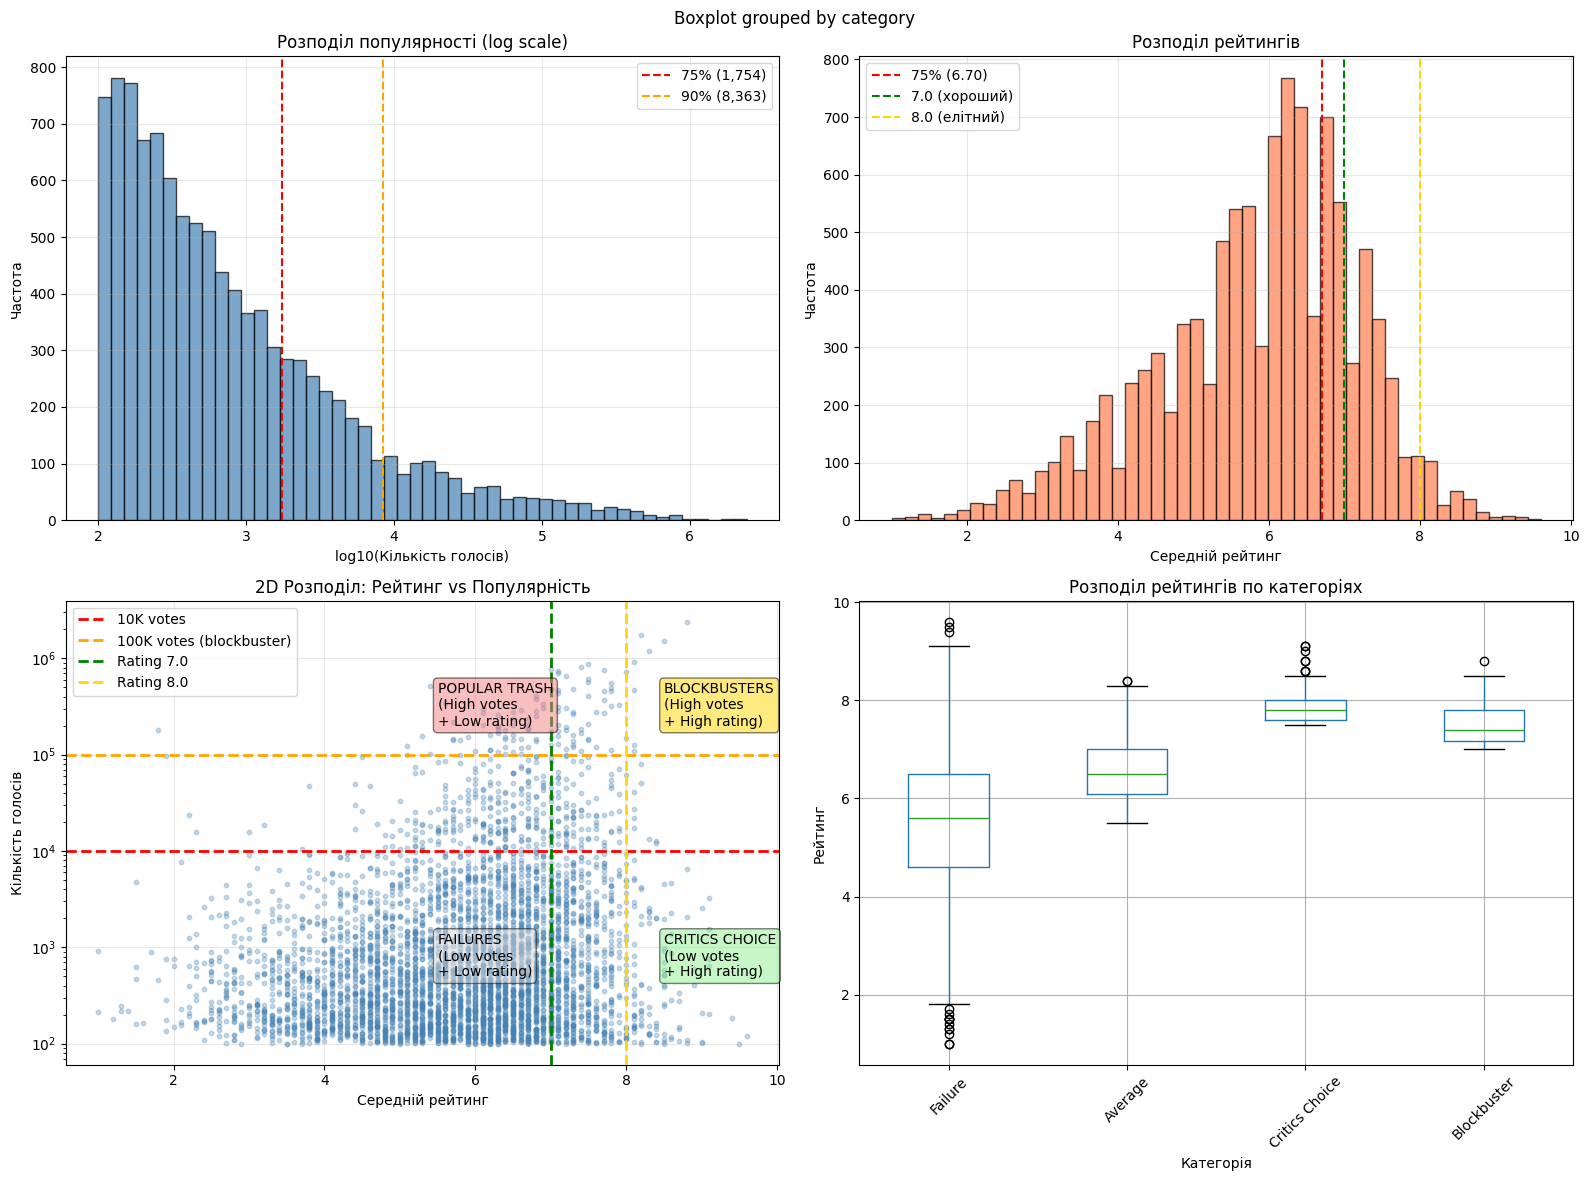


✅ Візуалізацію збережено: visualizations/success_criteria_distribution.png


In [6]:
# Візуалізація розподілів
movies_pd = movies.select("numVotes", "averageRating").sample(fraction=0.1, seed=42).toPandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Розподіл популярності та рейтингів фільмів', fontsize=16, fontweight='bold')

# 1. Розподіл numVotes (log scale)
ax1 = axes[0, 0]
ax1.hist(np.log10(movies_pd['numVotes']), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('log10(Кількість голосів)')
ax1.set_ylabel('Частота')
ax1.set_title('Розподіл популярності (log scale)')
ax1.axvline(np.log10(votes_quantiles[2]), color='red', linestyle='--', label=f'75% ({votes_quantiles[2]:,.0f})')
ax1.axvline(np.log10(votes_quantiles[3]), color='orange', linestyle='--', label=f'90% ({votes_quantiles[3]:,.0f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Розподіл averageRating
ax2 = axes[0, 1]
ax2.hist(movies_pd['averageRating'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Середній рейтинг')
ax2.set_ylabel('Частота')
ax2.set_title('Розподіл рейтингів')
ax2.axvline(rating_quantiles[2], color='red', linestyle='--', label=f'75% ({rating_quantiles[2]:.2f})')
ax2.axvline(7.0, color='green', linestyle='--', label='7.0 (хороший)')
ax2.axvline(8.0, color='gold', linestyle='--', label='8.0 (елітний)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. 2D Scatter: votes vs rating (КЛЮЧОВА ВІЗУАЛІЗАЦІЯ!)
ax3 = axes[1, 0]
# Семплюємо для швидкості
sample_pd = movies_pd.sample(min(5000, len(movies_pd)))
scatter = ax3.scatter(sample_pd['averageRating'], sample_pd['numVotes'],
                     alpha=0.3, s=10, c='steelblue')
ax3.set_xlabel('Середній рейтинг')
ax3.set_ylabel('Кількість голосів')
ax3.set_yscale('log')
ax3.set_title('2D Розподіл: Рейтинг vs Популярність')

# Додаємо лінії для квадрантів
ax3.axhline(10000, color='red', linestyle='--', linewidth=2, label='10K votes')
ax3.axhline(100000, color='orange', linestyle='--', linewidth=2, label='100K votes (blockbuster)')
ax3.axvline(7.0, color='green', linestyle='--', linewidth=2, label='Rating 7.0')
ax3.axvline(8.0, color='gold', linestyle='--', linewidth=2, label='Rating 8.0')

# Підписуємо квадранти
ax3.text(8.5, 200000, 'BLOCKBUSTERS\n(High votes\n+ High rating)', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='gold', alpha=0.5))
ax3.text(8.5, 500, 'CRITICS CHOICE\n(Low votes\n+ High rating)', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax3.text(5.5, 200000, 'POPULAR TRASH\n(High votes\n+ Low rating)', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))
ax3.text(5.5, 500, 'FAILURES\n(Low votes\n+ Low rating)', 
         fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# 4. Box plots порівняння
ax4 = axes[1, 1]
# Створюємо категорії для box plot
sample_pd['category'] = 'Average'
sample_pd.loc[(sample_pd['numVotes'] >= 100000) & (sample_pd['averageRating'] >= 7.0), 'category'] = 'Blockbuster'
sample_pd.loc[(sample_pd['numVotes'] < 10000) & (sample_pd['averageRating'] >= 7.5), 'category'] = 'Critics Choice'
sample_pd.loc[(sample_pd['numVotes'] < 1000) | (sample_pd['averageRating'] < 5.5), 'category'] = 'Failure'

categories_order = ['Failure', 'Average', 'Critics Choice', 'Blockbuster']
sample_pd['category'] = pd.Categorical(sample_pd['category'], categories=categories_order, ordered=True)

sample_pd.boxplot(column='averageRating', by='category', ax=ax4)
ax4.set_xlabel('Категорія')
ax4.set_ylabel('Рейтинг')
ax4.set_title('Розподіл рейтингів по категоріях')
plt.sca(ax4)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('/app/visualizations/success_criteria_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Візуалізацію збережено: visualizations/success_criteria_distribution.png")


## 4. Створення Target Variables (цільових змінних)

На основі аналізу розподілів створимо різні визначення "успіху"


In [16]:
# Створюємо TARGET VARIABLE на основі рейтингу (4 класи)

print("="*80)
print("СТВОРЕННЯ TARGET VARIABLE - ЯКІСТЬ ФІЛЬМУ (4 КЛАСИ)")
print("="*80)

# Визначення категорій на основі рейтингу
movies_with_targets = movies.withColumn(
    "quality_category",
    F.when(F.col("averageRating") < 4.0, "Poor")              # < 4.0: Погано
     .when(F.col("averageRating") < 6.0, "Average")           # 4.0-6.0: Середній
     .when(F.col("averageRating") < 8.0, "Good")              # 6.0-8.0: Нормальний
     .otherwise("Masterpiece")                                # 8.0-10.0: Шедевр
).withColumn(
    "quality_label",
    F.when(F.col("averageRating") < 4.0, 0)   # Poor
     .when(F.col("averageRating") < 6.0, 1)   # Average
     .when(F.col("averageRating") < 8.0, 2)   # Good
     .otherwise(3)                             # Masterpiece
)

print("\n🎯 КАТЕГОРІЇ ЯКОСТІ:")
print("  0 - Poor        (rating < 4.0):  Погано")
print("  1 - Average     (rating 4.0-6.0): Середній фільм")
print("  2 - Good        (rating 6.0-8.0): Нормальний фільм")
print("  3 - Masterpiece (rating 8.0-10.0): Шедевр")

# Аналіз розподілу класів
print("\n" + "="*80)
print("РОЗПОДІЛ КЛАСІВ (Class Distribution)")
print("="*80)

class_dist = movies_with_targets.groupBy("quality_label", "quality_category").count().orderBy("quality_label")
total_count = movies_with_targets.count()

print("\n📊 Детальний розподіл:")
for row in class_dist.collect():
    label = row['quality_label']
    category = row['quality_category']
    count = row['count']
    pct = count / total_count * 100
    
    # Emoji для кожної категорії
    emoji = {0: "💩", 1: "😐", 2: "👍", 3: "🏆"}[label]
    
    print(f"  {emoji} {label}. {category:12} (rating {['<4.0', '4.0-6.0', '6.0-8.0', '8.0-10.0'][label]:9}): {count:>8,} ({pct:>5.1f}%)")

# Перевірка на class imbalance
print("\n" + "="*80)
print("⚠️ CLASS IMBALANCE CHECK")
print("="*80)

min_class = class_dist.collect()[0]['count']
max_class = class_dist.collect()[-1]['count']
imbalance_ratio = min_class / total_count

print(f"Найбільший клас: {max_class:,} фільмів")
print(f"Найменший клас:  {min_class:,} фільмів")
print(f"Imbalance ratio: {imbalance_ratio*100:.1f}% (частка найменшого класу)")

if imbalance_ratio < 0.15:
    print(f"\n⚠️  WARNING: Виявлено значний imbalance ({imbalance_ratio*100:.1f}%)!")
    print("   Буде потрібне балансування даних")
else:
    print(f"\n✅ Класи відносно збалансовані ({imbalance_ratio*100:.1f}%)")


СТВОРЕННЯ TARGET VARIABLE - ЯКІСТЬ ФІЛЬМУ (4 КЛАСИ)

🎯 КАТЕГОРІЇ ЯКОСТІ:
  0 - Poor        (rating < 4.0):  Погано
  1 - Average     (rating 4.0-6.0): Середній фільм
  2 - Good        (rating 6.0-8.0): Нормальний фільм
  3 - Masterpiece (rating 8.0-10.0): Шедевр

РОЗПОДІЛ КЛАСІВ (Class Distribution)



📊 Детальний розподіл:


  💩 0. Poor         (rating <4.0     ):   10,511 ( 10.0%)
  😐 1. Average      (rating 4.0-6.0  ):   40,394 ( 38.5%)
  👍 2. Good         (rating 6.0-8.0  ):   50,843 ( 48.5%)
  🏆 3. Masterpiece  (rating 8.0-10.0 ):    3,048 (  2.9%)

⚠️ CLASS IMBALANCE CHECK
Найбільший клас: 3,048 фільмів
Найменший клас:  10,511 фільмів
Imbalance ratio: 10.0% (частка найменшого класу)

⚠️  WARNING: Виявлено значний imbalance (10.0%)!
   Буде потрібне балансування даних


/tmp/ipykernel_4366/502079295.py:70: UserWarning: Glyph 128169 (\N{PILE OF POO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4366/502079295.py:70: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4366/502079295.py:70: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4366/502079295.py:71: UserWarning: Glyph 128169 (\N{PILE OF POO}) missing from font(s) DejaVu Sans.
  plt.savefig('/app/visualizations/class_distribution.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_4366/502079295.py:71: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig('/app/visualizations/class_distribution.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_4366/502079295.py:71: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('/app/visualizations/class_distribution.png', dpi=300, bb

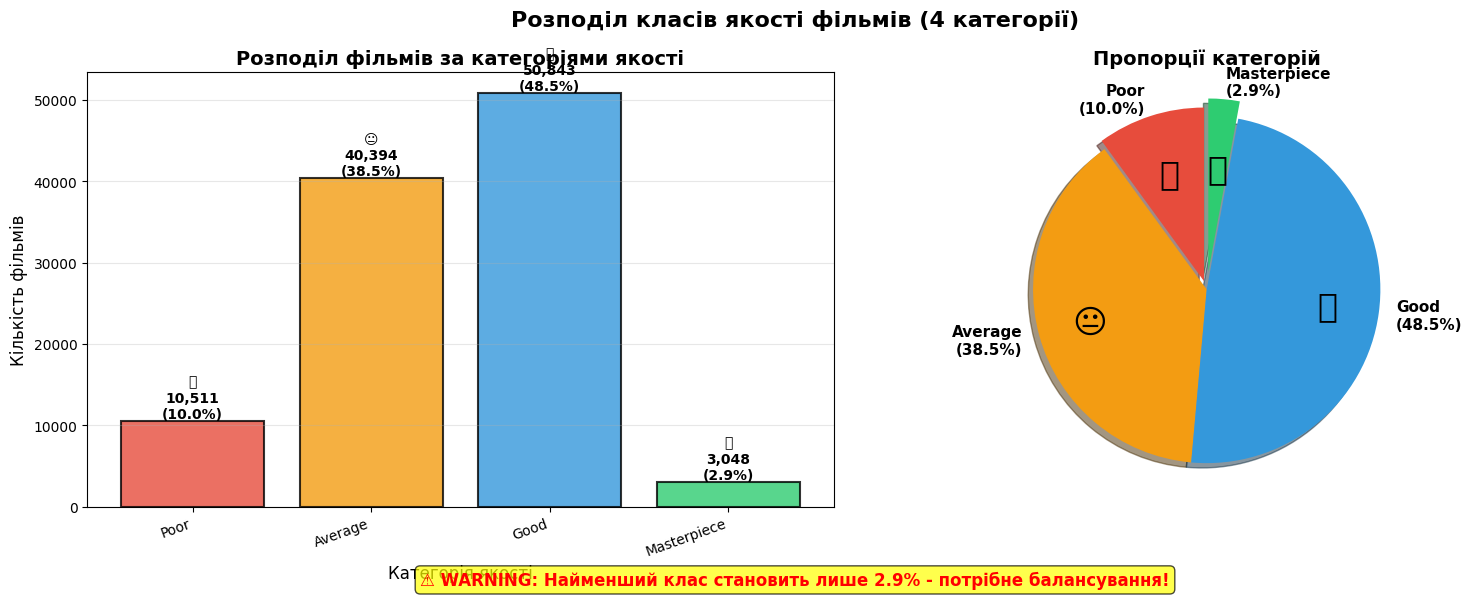


✅ Візуалізацію збережено: visualizations/class_distribution.png


In [17]:
# Візуалізація розподілу класів
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Розподіл класів якості фільмів (4 категорії)', fontsize=16, fontweight='bold')

# Підготовка даних
quality_dist = movies_with_targets.groupBy("quality_label", "quality_category").count().orderBy("quality_label").collect()
labels = [row['quality_label'] for row in quality_dist]
categories = [row['quality_category'] for row in quality_dist]
counts = [row['count'] for row in quality_dist]
total = sum(counts)

# Кольори для кожної категорії
colors_quality = {
    0: '#e74c3c',      # Poor - червоний
    1: '#f39c12',      # Average - помаранчевий
    2: '#3498db',      # Good - синій
    3: '#2ecc71'       # Masterpiece - зелений
}
bar_colors = [colors_quality[label] for label in labels]

# 1. Bar Chart - розподіл по класах
ax1 = axes[0]
bars1 = ax1.bar(categories, counts, color=bar_colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Кількість фільмів', fontsize=12)
ax1.set_xlabel('Категорія якості', fontsize=12)
ax1.set_title('Розподіл фільмів за категоріями якості', fontsize=14, fontweight='bold')

# Додаємо значення на стовпці
for i, (bar, count, label) in enumerate(zip(bars1, counts, labels)):
    height = bar.get_height()
    pct = count / total * 100
    emoji = {0: "💩", 1: "😐", 2: "👍", 3: "🏆"}[label]
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{emoji}\n{int(count):,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
plt.sca(ax1)
plt.xticks(rotation=20, ha='right')

# 2. Pie Chart - пропорції
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts, 
    labels=[f'{cat}\n({pct:.1f}%)' for cat, pct in zip(categories, [c/total*100 for c in counts])],
    colors=bar_colors,
    autopct='',
    startangle=90,
    explode=[0.05, 0, 0, 0.1],  # Виділяємо Poor та Masterpiece
    shadow=True,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# Додаємо emoji в центр кожного сектору
for i, (wedge, label) in enumerate(zip(wedges, labels)):
    ang = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
    x = np.cos(np.deg2rad(ang)) * 0.7
    y = np.sin(np.deg2rad(ang)) * 0.7
    emoji = {0: "💩", 1: "😐", 2: "👍", 3: "🏆"}[label]
    ax2.text(x, y, emoji, ha='center', va='center', fontsize=24)

ax2.set_title('Пропорції категорій', fontsize=14, fontweight='bold')

# Перевірка imbalance
min_class_pct = min(counts) / total * 100
if min_class_pct < 10:
    fig.text(0.5, 0.02, f'⚠️ WARNING: Найменший клас становить лише {min_class_pct:.1f}% - потрібне балансування!',
             ha='center', fontsize=12, color='red', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig('/app/visualizations/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Візуалізацію збережено: visualizations/class_distribution.png")


## 5. Feature Engineering - Підготовка ознак для ML

Створимо фічі які будуть доступні ДО випуску фільму (тобто, не використовуємо numVotes та rating як фічі!)


In [19]:
# Створюємо фічі які можна знати ДО випуску фільму

print("="*80)
print("FEATURE ENGINEERING - Розширений набір ознак")
print("="*80)

# 1. Обробка жанрів - створюємо бінарні фічі для топ-жанрів
from pyspark.sql.functions import explode, split

# Знаходимо топ-10 жанрів
top_genres = movies_with_targets.select(
    explode(split(F.col("genres"), ",")).alias("genre")
).groupBy("genre").count().orderBy(F.desc("count")).limit(10).select("genre").rdd.flatMap(lambda x: x).collect()

print(f"\n1️⃣ ЖАНРИ - Топ-10: {top_genres}")

# Створюємо бінарні ознаки для кожного топ-жанру
movies_featured = movies_with_targets
for genre in top_genres:
    col_name = f"is_{genre.replace('-', '_')}"
    movies_featured = movies_featured.withColumn(
        col_name,
        F.when(F.col("genres").contains(genre), 1).otherwise(0)
    )

# 2. Інформація про АКТОРІВ та РЕЖИСЕРІВ з title.principals
print("\n2️⃣ АКТОРИ ТА РЕЖИСЕРИ (з title.principals)...")

title_principals = dataframes["title.principals"]

# Кількість акторів
actors_count = title_principals.filter(
    F.col("category").isin(["actor", "actress"])
).groupBy("tconst").agg(
    F.count("*").alias("num_actors")
)

# Кількість режисерів
directors_count = title_principals.filter(
    F.col("category") == "director"
).groupBy("tconst").agg(
    F.count("*").alias("num_directors")
)

# Інформація про відомих акторів (топ-500 за кількістю фільмів)
top_actors = title_principals.filter(
    F.col("category").isin(["actor", "actress"])
).groupBy("nconst").agg(
    F.count("*").alias("film_count")
).orderBy(F.desc("film_count")).limit(500).select("nconst")

# Чи є топ-актори в фільмі
films_with_top_actors = title_principals.join(
    top_actors, "nconst", "inner"
).groupBy("tconst").agg(
    F.count("*").alias("num_top_actors")
)

# Об'єднуємо з movies_featured
movies_featured = movies_featured.join(actors_count, "tconst", "left")
movies_featured = movies_featured.join(directors_count, "tconst", "left")
movies_featured = movies_featured.join(films_with_top_actors, "tconst", "left")

print(f"   ✅ Додано: num_actors, num_directors, num_top_actors")

# 3. КРАЇНА виробництва (з title.akas - беремо найчастіший регіон)
print("\n3️⃣ КРАЇНА виробництва (з title.akas)...")

title_akas = dataframes["title.akas"]

# Визначаємо primary region (найчастіший)
region_counts = title_akas.filter(
    F.col("region").isNotNull()
).groupBy("titleId", "region").agg(
    F.count("*").alias("region_count")
)

window = Window.partitionBy("titleId").orderBy(F.desc("region_count"))
primary_region = region_counts.withColumn(
    "rank", F.row_number().over(window)
).filter(
    F.col("rank") == 1
).select(
    F.col("titleId").alias("tconst"),
    F.col("region").alias("country")
)

# Топ-10 країн-виробників
top_countries_raw = primary_region.groupBy("country").count().orderBy(
    F.desc("count")
).limit(10).select("country").rdd.flatMap(lambda x: x).collect()

# Фільтруємо країни без спеціальних символів та створюємо safe names
import re
top_countries = []
top_countries_safe = []
for country in top_countries_raw:
    # Skip країни зі спеціальними символами (backslash, quotes, etc.)
    if country and re.match(r'^[A-Za-z0-9_-]+$', country):
        top_countries.append(country)
        # Safe column name (тільки букви/цифри)
        safe_name = re.sub(r'[^A-Za-z0-9]', '_', country)
        top_countries_safe.append(safe_name)
    if len(top_countries) >= 10:
        break

print(f"   Топ-{len(top_countries)} країн (відфільтровано спеціальні символи): {top_countries}")

# Об'єднуємо з movies_featured
movies_featured = movies_featured.join(primary_region, "tconst", "left")

# Створюємо бінарні фічі для топ-країн
for country, safe_name in zip(top_countries, top_countries_safe):
    col_name = f"is_country_{safe_name}"
    movies_featured = movies_featured.withColumn(
        col_name,
        F.when(F.col("country") == country, 1).otherwise(0)
    )

print(f"   ✅ Додано: country + {len(top_countries_safe)} бінарних фічей для країн")

# 4. БЮДЖЕТ PROXY - оцінюємо масштаб виробництва
print("\n4️⃣ БЮДЖЕТ PROXY (production scale indicators)...")

# Budget proxy = num_actors + num_directors + num_countries + runtime
# Більше акторів/режисерів/країн = більший бюджет (зазвичай)

# Кількість країн де випущено (з title.akas)
countries_count = title_akas.groupBy("titleId").agg(
    F.countDistinct("region").alias("num_countries_released")
)

movies_featured = movies_featured.join(
    countries_count.withColumnRenamed("titleId", "tconst"), 
    "tconst", 
    "left"
)

# Production scale score (композитна метрика)
movies_featured = movies_featured.withColumn(
    "production_scale",
    (F.coalesce(F.col("num_actors"), F.lit(0)) * 2) +
    (F.coalesce(F.col("num_directors"), F.lit(0)) * 5) +
    (F.coalesce(F.col("num_top_actors"), F.lit(0)) * 10) +
    (F.coalesce(F.col("num_countries_released"), F.lit(0)) * 3) +
    (F.col("runtimeMinutes") / 30)  # Довші фільми часто дорожчі
)

print(f"   ✅ Додано: num_countries_released, production_scale")

# 5. Часові фічі (БЕЗ age_of_film та is_golden_age!)
movies_featured = movies_featured.withColumn(
    "is_modern",  # 2010+
    F.when(F.col("startYear") >= 2010, 1).otherwise(0)
).withColumn(
    "decade",
    (F.col("startYear") / 10).cast("int") * 10  # 1980, 1990, 2000, etc.
)

# 6. Runtime категорії (з безпечним overflow handling)
movies_featured = movies_featured.withColumn(
    "runtime_squared",
    # Cast to double для уникнення integer overflow
    (F.col("runtimeMinutes").cast("double") * F.col("runtimeMinutes").cast("double"))
)

# Список ВСІХ фічей
feature_columns = (
    # Базові
    ["startYear", "runtimeMinutes", "runtime_squared", "numGenres", "decade", "is_modern"] +
    # Жанри (10)
    [f"is_{genre.replace('-', '_')}" for genre in top_genres] +
    # Актори та режисери (3)
    ["num_actors", "num_directors", "num_top_actors"] +
    # Країни (використовуємо safe names!)
    [f"is_country_{safe_name}" for safe_name in top_countries_safe] +
    # Бюджет proxy (2)
    ["num_countries_released", "production_scale"]
)

print("\n" + "="*80)
print(f"✅ СТВОРЕНО {len(feature_columns)} ОЗНАК:")
print("="*80)

# Групуємо по категоріях
num_base = 6
num_genres = len(top_genres)
num_people = 3
num_countries = len(top_countries_safe)
num_budget = 2

print(f"\n📊 Базові фічі ({num_base}):")
print("   startYear, runtimeMinutes, runtime_squared, numGenres, decade, is_modern")

print(f"\n🎬 Жанри ({num_genres}):")
genre_features = [f"is_{g.replace('-', '_')}" for g in top_genres[:5]]
print(f"   {', '.join(genre_features)}...")

print(f"\n🎭 Актори/Режисери ({num_people}):")
print("   num_actors, num_directors, num_top_actors")

print(f"\n🌍 Країни ({num_countries}):")
country_features = [f"is_country_{c}" for c in top_countries_safe[:5]]
print(f"   {', '.join(country_features)}...")

print(f"\n💰 Бюджет proxy ({num_budget}):")
print("   num_countries_released, production_scale")

print(f"\n📈 Всього: {num_base} + {num_genres} + {num_people} + {num_countries} + {num_budget} = {len(feature_columns)} features")

# Фільтруємо записи з NULL значеннями та заповнюємо 0
movies_ml_ready = movies_featured.filter(
    F.col("runtimeMinutes").isNotNull()
).na.fill(0)  # Заповнюємо NULL нулями

print(f"\n✅ Підготовлено {movies_ml_ready.count():,} фільмів для ML")

# Показуємо приклад (включаючи target variable)
sample_features = ["tconst", "startYear", "num_actors", "num_directors", 
                   "num_top_actors", "production_scale", "country", "averageRating", 
                   "quality_label", "quality_category"]
print("\nПриклад даних (з target variable):")
movies_ml_ready.select(sample_features).show(5, truncate=False)


FEATURE ENGINEERING - Розширений набір ознак



1️⃣ ЖАНРИ - Топ-10: ['Drama', 'Comedy', 'Action', 'Romance', 'Thriller', 'Horror', 'Crime', 'Documentary', 'Adventure', 'Mystery']

2️⃣ АКТОРИ ТА РЕЖИСЕРИ (з title.principals)...
   ✅ Додано: num_actors, num_directors, num_top_actors

3️⃣ КРАЇНА виробництва (з title.akas)...


   Топ-9 країн (відфільтровано спеціальні символи): ['DE', 'ES', 'FR', 'US', 'IN', 'IT', 'JP', 'PT', 'GB']
   ✅ Додано: country + 9 бінарних фічей для країн

4️⃣ БЮДЖЕТ PROXY (production scale indicators)...
   ✅ Додано: num_countries_released, production_scale

✅ СТВОРЕНО 30 ОЗНАК:

📊 Базові фічі (6):
   startYear, runtimeMinutes, runtime_squared, numGenres, decade, is_modern

🎬 Жанри (10):
   is_Drama, is_Comedy, is_Action, is_Romance, is_Thriller...

🎭 Актори/Режисери (3):
   num_actors, num_directors, num_top_actors

🌍 Країни (9):
   is_country_DE, is_country_ES, is_country_FR, is_country_US, is_country_IN...

💰 Бюджет proxy (2):
   num_countries_released, production_scale

📈 Всього: 6 + 10 + 3 + 9 + 2 = 30 features



✅ Підготовлено 102,876 фільмів для ML

Приклад даних (з target variable):


+---------+---------+----------+-------------+--------------+-----------------+-------+-------------+-------------+----------------+
|tconst   |startYear|num_actors|num_directors|num_top_actors|production_scale |country|averageRating|quality_label|quality_category|
+---------+---------+----------+-------------+--------------+-----------------+-------+-------------+-------------+----------------+
|tt0038687|1980     |1         |0            |0             |39.93333333333333|BR     |7.4          |2            |Good            |
|tt0073537|1982     |10        |1            |0             |94.13333333333334|AT     |4.9          |1            |Average         |
|tt0075035|1982     |10        |1            |0             |94.0             |US     |3.5          |0            |Poor            |
|tt0076709|1980     |10        |1            |0             |127.2            |TR     |5.1          |1            |Average         |
|tt0077883|1980     |10        |1            |0             |59.2    

## 6. Підготовка даних та навчання моделей

Розділимо дані та навчимо кілька моделей для передбачення Commercial Success


In [20]:
# Фокусуємось на передбаченні якості фільму (4 класи: 0-Poor, 1-Average, 2-Good, 3-Masterpiece)
target_column = "quality_label"

# ВАЖЛИВО: Явно заповнюємо NULL для ВСІХ feature columns
# Створюємо dict для fillna з усіма колонками
fill_values = {col: 0 for col in feature_columns}

print("="*80)
print("ПІДГОТОВКА ДАНИХ ДЛЯ ML")
print("="*80)

# Перевіряємо скільки NULL значень у кожній колонці
print("\n🔍 Перевірка NULL значень у feature columns...")
null_counts = []
for col in feature_columns:
    null_count = movies_ml_ready.filter(F.col(col).isNull()).count()
    if null_count > 0:
        null_counts.append((col, null_count))
        
if null_counts:
    print(f"\n⚠️  Знайдено NULL значення в {len(null_counts)} колонках:")
    for col, count in null_counts[:10]:  # Показуємо перші 10
        print(f"   {col}: {count:,} NULL значень")
    if len(null_counts) > 10:
        print(f"   ... та ще {len(null_counts) - 10} колонок")
else:
    print("   ✅ NULL значень немає!")

# Заповнюємо NULL нулями для всіх feature columns
movies_ml_ready_filled = movies_ml_ready.fillna(fill_values)

print(f"\n✅ NULL значення заповнено нулями для {len(feature_columns)} фічей")

# Переконуємося що всі feature columns мають числовий тип
print("\n🔧 Конвертуємо всі фічі в числовий тип...")
for col in feature_columns:
    # Cast до double для безпеки
    movies_ml_ready_filled = movies_ml_ready_filled.withColumn(
        col, F.col(col).cast("double")
    )

# Створюємо feature vector
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
    handleInvalid="skip"  # На всякий випадок
)

# Застосовуємо assembler
print("\n🔧 Створення feature vectors...")
data_with_features = assembler.transform(movies_ml_ready_filled)

# Train/Test split (80/20)
train_data, test_data = data_with_features.randomSplit([0.8, 0.2], seed=42)

print("="*80)
print("РОЗДІЛЕННЯ ДАНИХ")
print("="*80)
train_count = train_data.count()
test_count = test_data.count()
print(f"Train set: {train_count:,} фільмів")
print(f"Test set:  {test_count:,} фільмів")

# Перевірка балансу в train/test для ВСІХ 4 класів
print("\nРозподіл по класах в Train set:")
train_class_dist = train_data.groupBy(target_column).count().orderBy(target_column).collect()
for row in train_class_dist:
    class_label = row[target_column]
    count = row['count']
    pct = count / train_count * 100
    class_name = {0: "Poor", 1: "Average", 2: "Good", 3: "Masterpiece"}[int(class_label)]
    emoji = {0: "💩", 1: "😐", 2: "👍", 3: "🏆"}[int(class_label)]
    print(f"  {emoji} {class_name:12}: {count:>8,} ({pct:>5.1f}%)")

print("\nРозподіл по класах в Test set:")
test_class_dist = test_data.groupBy(target_column).count().orderBy(target_column).collect()
for row in test_class_dist:
    class_label = row[target_column]
    count = row['count']
    pct = count / test_count * 100
    class_name = {0: "Poor", 1: "Average", 2: "Good", 3: "Masterpiece"}[int(class_label)]
    emoji = {0: "💩", 1: "😐", 2: "👍", 3: "🏆"}[int(class_label)]
    print(f"  {emoji} {class_name:12}: {count:>8,} ({pct:>5.1f}%)")

# Кешуємо для швидшого доступу
train_data.cache()
test_data.cache()

print("\n✅ Дані підготовлено та закешовано")


ПІДГОТОВКА ДАНИХ ДЛЯ ML

🔍 Перевірка NULL значень у feature columns...
   ✅ NULL значень немає!

✅ NULL значення заповнено нулями для 30 фічей

🔧 Конвертуємо всі фічі в числовий тип...

🔧 Створення feature vectors...
РОЗДІЛЕННЯ ДАНИХ


Train set: 82,503 фільмів
Test set:  20,373 фільмів

Розподіл по класах в Train set:


  💩 Poor        :    8,172 (  9.9%)
  😐 Average     :   31,693 ( 38.4%)
  👍 Good        :   40,337 ( 48.9%)
  🏆 Masterpiece :    2,301 (  2.8%)

Розподіл по класах в Test set:


  💩 Poor        :    2,059 ( 10.1%)
  😐 Average     :    7,985 ( 39.2%)
  👍 Good        :    9,763 ( 47.9%)
  🏆 Masterpiece :      566 (  2.8%)

✅ Дані підготовлено та закешовано


### 6.1 Балансування даних (Class Balancing)


In [21]:
# Перевірка поточного балансу для MULTI-CLASS (4 класи)
print("="*80)
print("ПОЧАТКОВИЙ РОЗПОДІЛ TRAIN SET (Multi-class)")
print("="*80)

# Рахуємо кількість зразків для кожного класу
class_counts = {}
class_fractions = {}
total = train_data.count()

for class_label in [0, 1, 2, 3]:
    count = train_data.filter(F.col(target_column) == class_label).count()
    class_counts[class_label] = count
    class_fractions[class_label] = count / total
    class_name = {0: "Poor", 1: "Average", 2: "Good", 3: "Masterpiece"}[class_label]
    emoji = {0: "💩", 1: "😐", 2: "👍", 3: "🏆"}[class_label]
    print(f"{emoji} {class_name:12}: {count:>8,} ({count/total*100:>5.1f}%)")

# Знаходимо найменший та найбільший клас
min_count = min(class_counts.values())
max_count = max(class_counts.values())
imbalance_ratio = min_count / total

print(f"\nНайбільший клас: {max_count:,}")
print(f"Найменший клас:  {min_count:,}")
print(f"Imbalance ratio: {imbalance_ratio*100:.1f}%")

# СТРАТЕГІЯ: Для multi-class використовуємо ПІДХІД 1: Weighted Training
# (тобто НЕ підсампліюємо дані, а використовуємо weightCol при тренуванні)

print("\n" + "="*80)
print("СТРАТЕГІЯ БАЛАНСУВАННЯ: Class Weights")
print("="*80)

# Розраховуємо ваги для кожного класу (inversely proportional to class frequency)
# weight = total_samples / (n_classes * class_count)
n_classes = 4
class_weights = {}
for class_label, count in class_counts.items():
    weight = total / (n_classes * count)
    class_weights[class_label] = weight
    class_name = {0: "Poor", 1: "Average", 2: "Good", 3: "Masterpiece"}[class_label]
    print(f"{class_name:12}: weight = {weight:.3f}")

# Додаємо колонку з вагами до train_data
from pyspark.sql.functions import when

# Створюємо expression для weight column
weight_expr = when(F.col(target_column) == 0, class_weights[0])
for class_label in [1, 2, 3]:
    weight_expr = weight_expr.when(F.col(target_column) == class_label, class_weights[class_label])

train_balanced = train_data.withColumn("weight", weight_expr)

print(f"\n✅ Додано колонку 'weight' до train set")
print("   Моделі будуть тренуватись з weighted samples!")
print("   Це дозволяє зберегти всі дані та уникнути imbalance bias")

# Кешуємо
train_balanced.cache()

print("\n✅ Дані готові до навчання з class weights!")


ПОЧАТКОВИЙ РОЗПОДІЛ TRAIN SET (Multi-class)


💩 Poor        :    8,172 (  9.9%)
😐 Average     :   31,693 ( 38.4%)
👍 Good        :   40,337 ( 48.9%)
🏆 Masterpiece :    2,301 (  2.8%)

Найбільший клас: 40,337
Найменший клас:  2,301
Imbalance ratio: 2.8%

СТРАТЕГІЯ БАЛАНСУВАННЯ: Class Weights
Poor        : weight = 2.524
Average     : weight = 0.651
Good        : weight = 0.511
Masterpiece : weight = 8.964

✅ Додано колонку 'weight' до train set
   Моделі будуть тренуватись з weighted samples!
   Це дозволяє зберегти всі дані та уникнути imbalance bias

✅ Дані готові до навчання з class weights!


/tmp/ipykernel_4366/1669748675.py:59: UserWarning: Glyph 128169 (\N{PILE OF POO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4366/1669748675.py:59: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4366/1669748675.py:59: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4366/1669748675.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4366/1669748675.py:60: UserWarning: Glyph 128169 (\N{PILE OF POO}) missing from font(s) DejaVu Sans.
  plt.savefig('/app/visualizations/class_weights.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_4366/1669748675.py:60: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  plt.savefig('/app/visualizations/class_weights.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_4366/1669748675.py:60: Us

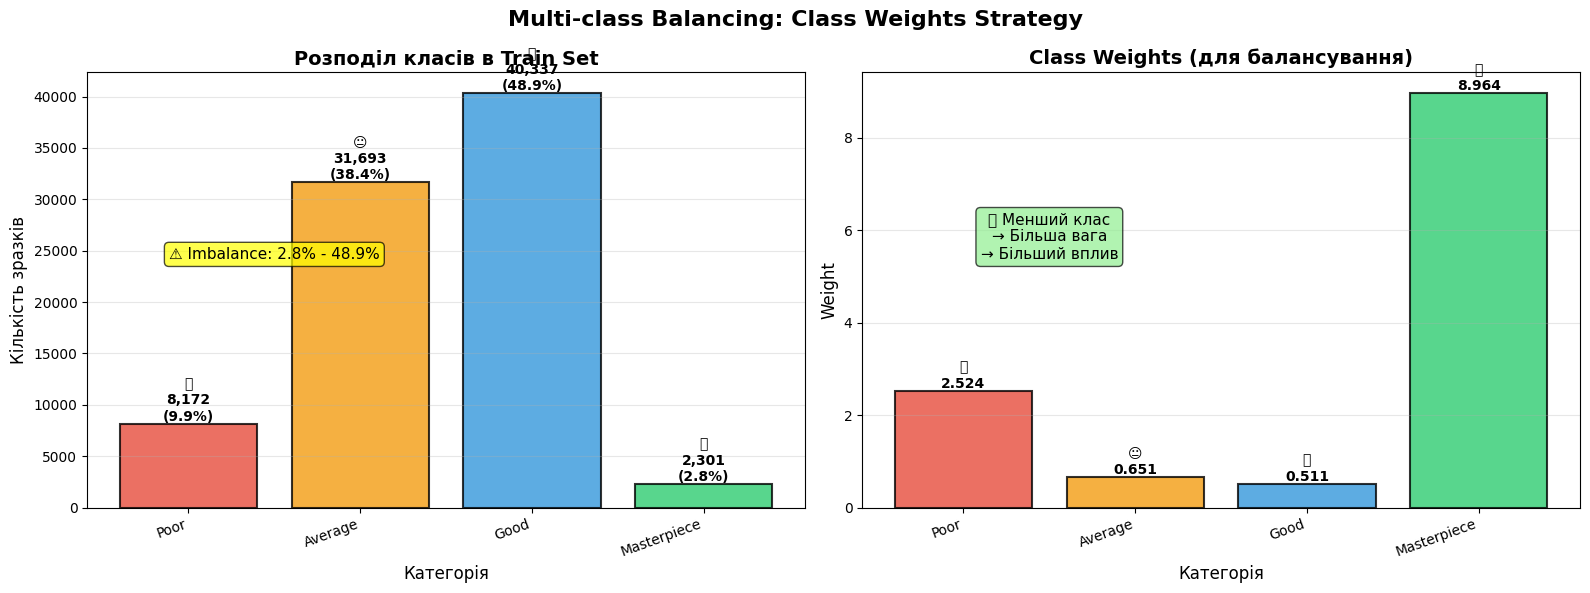

✅ Візуалізацію збережено: visualizations/class_weights.png

💡 Weighted Training Strategy:
   - Кожен клас отримує вагу inversely proportional до його частоти
   - Це дозволяє моделі однаково зважати ВСІ класи під час навчання
   - Зберігаємо ВСІ дані (не втрачаємо інформацію через undersampling)


In [24]:
# Візуалізація розподілу класів та їх ваг
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Multi-class Balancing: Class Weights Strategy', fontsize=16, fontweight='bold')

# 1. Розподіл класів
ax1 = axes[0]
class_names = ['Poor', 'Average', 'Good', 'Masterpiece']
class_counts_list = [class_counts[i] for i in range(4)]
colors_quality = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
emojis = ['💩', '😐', '👍', '🏆']

bars1 = ax1.bar(class_names, class_counts_list, color=colors_quality, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_ylabel('Кількість зразків', fontsize=12)
ax1.set_xlabel('Категорія', fontsize=12)
ax1.set_title('Розподіл класів в Train Set', fontsize=14, fontweight='bold')

for i, bar in enumerate(bars1):
    height = bar.get_height()
    pct = height / total * 100
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{emojis[i]}\n{int(height):,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
plt.sca(ax1)
plt.xticks(rotation=20, ha='right')

# Показуємо imbalance
min_pct = min(class_counts_list) / total * 100
max_pct = max(class_counts_list) / total * 100
ax1.text(0.5, max(class_counts_list) * 0.6,
         f'⚠️ Imbalance: {min_pct:.1f}% - {max_pct:.1f}%',
         ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# 2. Class Weights
ax2 = axes[1]
class_weights_list = [class_weights[i] for i in range(4)]

bars2 = ax2.bar(class_names, class_weights_list, color=colors_quality, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('Weight', fontsize=12)
ax2.set_xlabel('Категорія', fontsize=12)
ax2.set_title('Class Weights (для балансування)', fontsize=14, fontweight='bold')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{emojis[i]}\n{height:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
plt.sca(ax2)
plt.xticks(rotation=20, ha='right')

# Пояснення
ax2.text(0.5, max(class_weights_list) * 0.6,
         '✅ Менший клас\n→ Більша вага\n→ Більший вплив',
         ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig('/app/visualizations/class_weights.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Візуалізацію збережено: visualizations/class_weights.png")
print("\n💡 Weighted Training Strategy:")
print("   - Кожен клас отримує вагу inversely proportional до його частоти")
print("   - Це дозволяє моделі однаково зважати ВСІ класи під час навчання")
print("   - Зберігаємо ВСІ дані (не втрачаємо інформацію через undersampling)")


### 6.2 Навчання моделей на збалансованих даних


#### Модель 1: Logistic Regression


In [27]:
# Logistic Regression для MULTI-CLASS (4 класи) з weighted training
lr = LogisticRegression(
    featuresCol="features",
    labelCol=target_column,
    weightCol="weight",  # ⭐ Використовуємо ваги для балансування!
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.5,
    family="multinomial"  # ⭐ Для multi-class!
)

# Навчання
import time
start_time = time.time()
lr_model = lr.fit(train_balanced)  # train_balanced містить колонку 'weight'
training_time_lr = time.time() - start_time

# Передбачення на тестовому наборі
lr_predictions = lr_model.transform(test_data)

# Evaluators для MULTI-CLASS
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol=target_column, predictionCol="prediction", metricName="accuracy"
)
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol=target_column, predictionCol="prediction", metricName="f1"
)
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol=target_column, predictionCol="prediction", metricName="weightedPrecision"
)
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol=target_column, predictionCol="prediction", metricName="weightedRecall"
)

# Обчислюємо метрики
lr_accuracy = evaluator_acc.evaluate(lr_predictions)
lr_f1 = evaluator_f1.evaluate(lr_predictions)
lr_precision = evaluator_precision.evaluate(lr_predictions)
lr_recall = evaluator_recall.evaluate(lr_predictions)

print("="*80)
print("LOGISTIC REGRESSION (Multi-class) - Результати")
print("="*80)
print(f"Training time: {training_time_lr:.2f}s")
print(f"Training samples: {train_balanced.count():,} (with class weights)")
print(f"\nTest Metrics:")
print(f"  Accuracy:            {lr_accuracy:.4f} ⭐")
print(f"  F1 Score (weighted): {lr_f1:.4f}")
print(f"  Precision (weighted):{lr_precision:.4f}")
print(f"  Recall (weighted):   {lr_recall:.4f}")

# Confusion Matrix для multi-class (використовуємо PySpark)
print(f"\nConfusion Matrix (4x4):")
print("="*60)

# Створюємо confusion matrix вручну через PySpark
cm_data = []
class_labels = [0, 1, 2, 3]
class_names = ['Poor', 'Average', 'Good', 'Masterpiece']

for actual_label in class_labels:
    row = []
    for pred_label in class_labels:
        count = lr_predictions.filter(
            (F.col(target_column) == actual_label) & (F.col("prediction") == pred_label)
        ).count()
        row.append(count)
    cm_data.append(row)

# Виводимо confusion matrix
print("Actual  |  Predicted →")
print("        |  Poor   Avg   Good  Master")
print("-" * 60)
for i, (label, row) in enumerate(zip(class_names, cm_data)):
    row_total = sum(row)
    print(f"{label:8}|", end="")
    for count in row:
        print(f" {count:>5,}", end="")
    print(f"  | Total: {row_total:,}")

# Детальні метрики по кожному класу
print("\n" + "="*80)
print("ДЕТАЛЬНІ МЕТРИКИ ПО КЛАСАХ:")
print("="*80)

for class_label, class_name in enumerate(class_names):
    # True Positives, False Positives, False Negatives для кожного класу
    tp = cm_data[class_label][class_label]
    fp = sum([cm_data[i][class_label] for i in range(4)]) - tp
    fn = sum(cm_data[class_label]) - tp
    tn = sum([sum(row) for row in cm_data]) - tp - fp - fn
    
    # Метрики
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    support = tp + fn
    
    emoji = {0: "💩", 1: "😐", 2: "👍", 3: "🏆"}[class_label]
    print(f"\n{emoji} {class_name} (label={class_label}):")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   Support:   {support:,} samples")

# Загальна accuracy
total_correct = sum([cm_data[i][i] for i in range(4)])
total_samples = sum([sum(row) for row in cm_data])
print(f"\n{'='*80}")
print(f"Overall Accuracy: {total_correct}/{total_samples} = {total_correct/total_samples:.4f}")
print(f"{'='*80}")


LOGISTIC REGRESSION (Multi-class) - Результати
Training time: 4.69s
Training samples: 82,503 (with class weights)

Test Metrics:
  Accuracy:            0.4286 ⭐
  F1 Score (weighted): 0.4587
  Precision (weighted):0.5486
  Recall (weighted):   0.4286

Confusion Matrix (4x4):
Actual  |  Predicted →
        |  Poor   Avg   Good  Master
------------------------------------------------------------
Poor    | 1,324   389   197   149  | Total: 2,059
Average | 2,365 2,656 2,170   794  | Total: 7,985
Good    |   902 1,829 4,395 2,637  | Total: 9,763
Masterpiece|    33    44   133   356  | Total: 566

ДЕТАЛЬНІ МЕТРИКИ ПО КЛАСАХ:

💩 Poor (label=0):
   Precision: 0.2863
   Recall:    0.6430
   F1-Score:  0.3962
   Support:   2,059 samples

😐 Average (label=1):
   Precision: 0.5401
   Recall:    0.3326
   F1-Score:  0.4117
   Support:   7,985 samples

👍 Good (label=2):
   Precision: 0.6374
   Recall:    0.4502
   F1-Score:  0.5277
   Support:   9,763 samples

🏆 Masterpiece (label=3):
   Precision: 

#### Модель 2: Random Forest


In [32]:
# Random Forest для MULTI-CLASS з weighted training
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=target_column,
    weightCol="weight",  # ⭐ Використовуємо ваги!
    numTrees=100,
    maxDepth=10,
    seed=42
)

# Навчання
start_time = time.time()
rf_model = rf.fit(train_balanced)
training_time_rf = time.time() - start_time

# Передбачення
rf_predictions = rf_model.transform(test_data)

# Метрики для multi-class
rf_accuracy = evaluator_acc.evaluate(rf_predictions)
rf_f1 = evaluator_f1.evaluate(rf_predictions)
rf_precision = evaluator_precision.evaluate(rf_predictions)
rf_recall = evaluator_recall.evaluate(rf_predictions)

print("="*80)
print("RANDOM FOREST (Multi-class) - Результати")
print("="*80)
print(f"Training time: {training_time_rf:.2f}s")
print(f"Num trees: {rf.getNumTrees()}, Max depth: {rf.getMaxDepth()}")
print(f"\nTest Metrics:")
print(f"  Accuracy:            {rf_accuracy:.4f} ⭐")
print(f"  F1 Score (weighted): {rf_f1:.4f}")
print(f"  Precision (weighted):{rf_precision:.4f}")
print(f"  Recall (weighted):   {rf_recall:.4f}")

# Confusion Matrix для multi-class (PySpark - без sklearn)
print(f"\nConfusion Matrix (4x4):")
print("="*60)

cm_rf_data = []
for actual_label in class_labels:
    row = []
    for pred_label in class_labels:
        count = rf_predictions.filter(
            (F.col(target_column) == actual_label) & (F.col("prediction") == pred_label)
        ).count()
        row.append(count)
    cm_rf_data.append(row)

print("Actual  |  Predicted →")
print("        |  Poor   Avg   Good  Master")
print("-" * 60)
for i, (label, row) in enumerate(zip(class_names, cm_rf_data)):
    row_total = sum(row)
    print(f"{label:8}|", end="")
    for count in row:
        print(f" {count:>5,}", end="")
    print(f"  | Total: {row_total:,}")

print(f"\n💡 Per-class accuracy:")
for class_label, class_name in enumerate(class_names):
    tp = cm_rf_data[class_label][class_label]
    support = sum(cm_rf_data[class_label])
    emoji = {0: "💩", 1: "😐", 2: "👍", 3: "🏆"}[class_label]
    print(f"  {emoji} {class_name}: {tp}/{support} correct ({tp/support*100:.1f}%)")


25/12/03 02:51:35 WARN DAGScheduler: Broadcasting large task binary with size 1489.2 KiB
25/12/03 02:51:36 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
25/12/03 02:51:37 WARN DAGScheduler: Broadcasting large task binary with size 4.2 MiB
25/12/03 02:51:37 WARN DAGScheduler: Broadcasting large task binary with size 1006.4 KiB
25/12/03 02:51:37 WARN DAGScheduler: Broadcasting large task binary with size 7.1 MiB
25/12/03 02:51:38 WARN DAGScheduler: Broadcasting large task binary with size 1658.2 KiB
25/12/03 02:51:39 WARN DAGScheduler: Broadcasting large task binary with size 11.8 MiB
25/12/03 02:51:40 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
25/12/03 02:51:41 WARN DAGScheduler: Broadcasting large task binary with size 9.1 MiB
25/12/03 02:51:41 WARN DAGScheduler: Broadcasting large task binary with size 9.1 MiB
25/12/03 02:51:42 WARN DAGScheduler: Broadcasting large task binary with size 9.1 MiB
25/12/03 02:51:42 WARN DAGScheduler: Broadca

RANDOM FOREST (Multi-class) - Результати
Training time: 7.25s
Num trees: 100, Max depth: 10

Test Metrics:
  Accuracy:            0.4636 ⭐
  F1 Score (weighted): 0.4939
  Precision (weighted):0.5823
  Recall (weighted):   0.4636

Confusion Matrix (4x4):


25/12/03 02:51:43 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:43 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:43 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:43 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:44 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:44 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:45 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:45 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:45 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:46 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:46 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB
25/12/03 02:51:46 WARN DAGScheduler: Broadcasting larg

Actual  |  Predicted →
        |  Poor   Avg   Good  Master
------------------------------------------------------------
Poor    | 1,351   440   125   143  | Total: 2,059
Average | 2,209 3,350 1,694   732  | Total: 7,985
Good    |   712 2,275 4,327 2,449  | Total: 9,763
Masterpiece|    18    35    97   416  | Total: 566

💡 Per-class accuracy:
  💩 Poor: 1351/2059 correct (65.6%)
  😐 Average: 3350/7985 correct (42.0%)
  👍 Good: 4327/9763 correct (44.3%)
  🏆 Masterpiece: 416/566 correct (73.5%)


25/12/03 02:51:47 WARN DAGScheduler: Broadcasting large task binary with size 9.0 MiB


#### Модель 3: Decision Tree Classifier


In [34]:
# Decision Tree Classifier для MULTI-CLASS з weighted training
# (GBT не підтримує multi-class, тому використовуємо Decision Tree)
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol=target_column,
    weightCol="weight",  # ⭐ Використовуємо ваги!
    maxDepth=10,
    seed=42
)

# Навчання
start_time = time.time()
dt_model = dt.fit(train_balanced)
training_time_dt = time.time() - start_time

# Передбачення
dt_predictions = dt_model.transform(test_data)

# Метрики для multi-class
dt_accuracy = evaluator_acc.evaluate(dt_predictions)
dt_f1 = evaluator_f1.evaluate(dt_predictions)
dt_precision = evaluator_precision.evaluate(dt_predictions)
dt_recall = evaluator_recall.evaluate(dt_predictions)

print("="*80)
print("DECISION TREE (Multi-class) - Результати")
print("="*80)
print(f"Training time: {training_time_dt:.2f}s")
print(f"Max depth: {dt.getMaxDepth()}")
print(f"\nTest Metrics:")
print(f"  Accuracy:            {dt_accuracy:.4f} ⭐")
print(f"  F1 Score (weighted): {dt_f1:.4f}")
print(f"  Precision (weighted):{dt_precision:.4f}")
print(f"  Recall (weighted):   {dt_recall:.4f}")

# Confusion Matrix для multi-class (PySpark - без sklearn)
print(f"\nConfusion Matrix (4x4):")
print("="*60)

cm_dt_data = []
for actual_label in class_labels:
    row = []
    for pred_label in class_labels:
        count = dt_predictions.filter(
            (F.col(target_column) == actual_label) & (F.col("prediction") == pred_label)
        ).count()
        row.append(count)
    cm_dt_data.append(row)

print("Actual  |  Predicted →")
print("        |  Poor   Avg   Good  Master")
print("-" * 60)
for i, (label, row) in enumerate(zip(class_names, cm_dt_data)):
    row_total = sum(row)
    print(f"{label:8}|", end="")
    for count in row:
        print(f" {count:>5,}", end="")
    print(f"  | Total: {row_total:,}")

print(f"\n💡 Per-class accuracy:")
for class_label, class_name in enumerate(class_names):
    tp = cm_dt_data[class_label][class_label]
    support = sum(cm_dt_data[class_label])
    emoji = {0: "💩", 1: "😐", 2: "👍", 3: "🏆"}[class_label]
    print(f"  {emoji} {class_name}: {tp}/{support} correct ({tp/support*100:.1f}%)")


DECISION TREE (Multi-class) - Результати
Training time: 1.54s
Max depth: 10

Test Metrics:
  Accuracy:            0.4371 ⭐
  F1 Score (weighted): 0.4617
  Precision (weighted):0.5567
  Recall (weighted):   0.4371

Confusion Matrix (4x4):
Actual  |  Predicted →
        |  Poor   Avg   Good  Master
------------------------------------------------------------
Poor    | 1,413   351   176   119  | Total: 2,059
Average | 2,764 2,327 2,242   652  | Total: 7,985
Good    | 1,028 1,565 4,795 2,375  | Total: 9,763
Masterpiece|    39    32   124   371  | Total: 566

💡 Per-class accuracy:
  💩 Poor: 1413/2059 correct (68.6%)
  😐 Average: 2327/7985 correct (29.1%)
  👍 Good: 4795/9763 correct (49.1%)
  🏆 Masterpiece: 371/566 correct (65.5%)


## 7. Візуалізація метрик та порівняння моделей


### 7.1 Confusion Matrices для всіх моделей


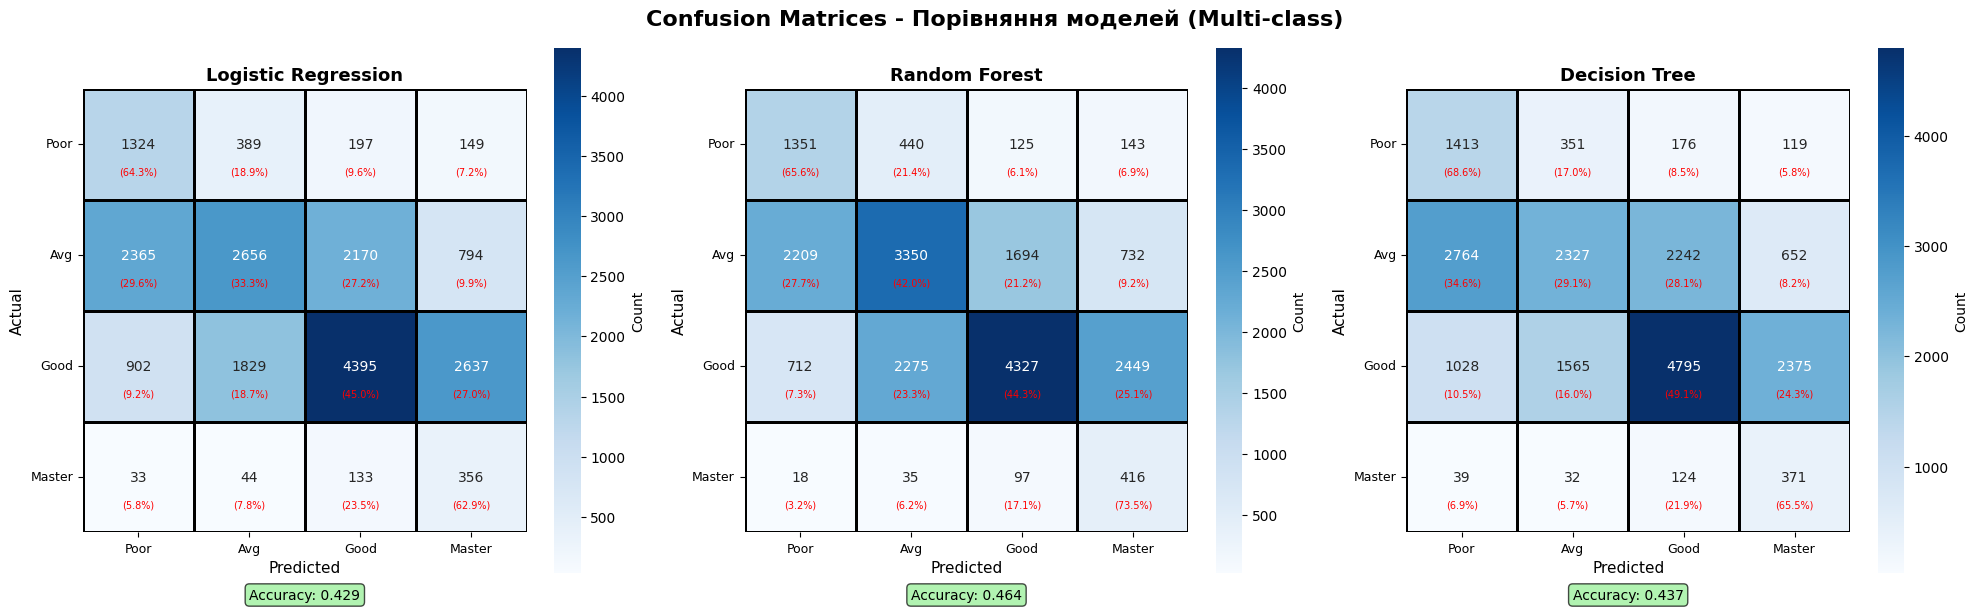

✅ Візуалізацію збережено: visualizations/confusion_matrices_comparison.png


In [36]:
# Візуалізація Confusion Matrices для MULTI-CLASS (4x4)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices - Порівняння моделей (Multi-class)', fontsize=16, fontweight='bold')

# Конвертуємо списки в numpy arrays для heatmap
models_cm = [
    ('Logistic Regression', np.array(cm_data)),
    ('Random Forest', np.array(cm_rf_data)),
    ('Decision Tree', np.array(cm_dt_data))
]

class_labels_short = ['Poor', 'Avg', 'Good', 'Master']

for idx, (name, cm) in enumerate(models_cm):
    ax = axes[idx]
    
    # Нормалізована confusion matrix для відсотків
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar=True, square=True, linewidths=1, linecolor='black',
                cbar_kws={'label': 'Count'})
    
    # Додаємо відсотки (менший шрифт для 4x4)
    for i in range(4):
        for j in range(4):
            text = ax.text(j + 0.5, i + 0.75, f'({cm_normalized[i, j]*100:.1f}%)',
                          ha="center", va="center", color="red", fontsize=7)
    
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xticklabels(class_labels_short, fontsize=9)
    ax.set_yticklabels(class_labels_short, fontsize=9, rotation=0)
    
    # Обчислюємо overall accuracy для кожної моделі
    total_correct = np.trace(cm)  # Сума діагоналі
    total_samples = np.sum(cm)
    accuracy = total_correct / total_samples
    
    # Додаємо accuracy знизу
    ax.text(0.5, -0.15, f'Accuracy: {accuracy:.3f}', 
            transform=ax.transAxes, ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.savefig('/app/visualizations/confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Візуалізацію збережено: visualizations/confusion_matrices_comparison.png")


### 7.2 Порівняння метрик моделей


ПОРІВНЯННЯ ВСІХ МОДЕЛЕЙ
              Model  Accuracy  F1 Score  Precision   Recall  Training Time (s)
Logistic Regression  0.428557  0.458664   0.548580 0.428557           4.692020
      Random Forest  0.463555  0.493916   0.582304 0.463555           7.245110
      Decision Tree  0.437147  0.461693   0.556690 0.437147           1.535376

🏆 НАЙКРАЩА МОДЕЛЬ: Random Forest
   Accuracy: 0.4636


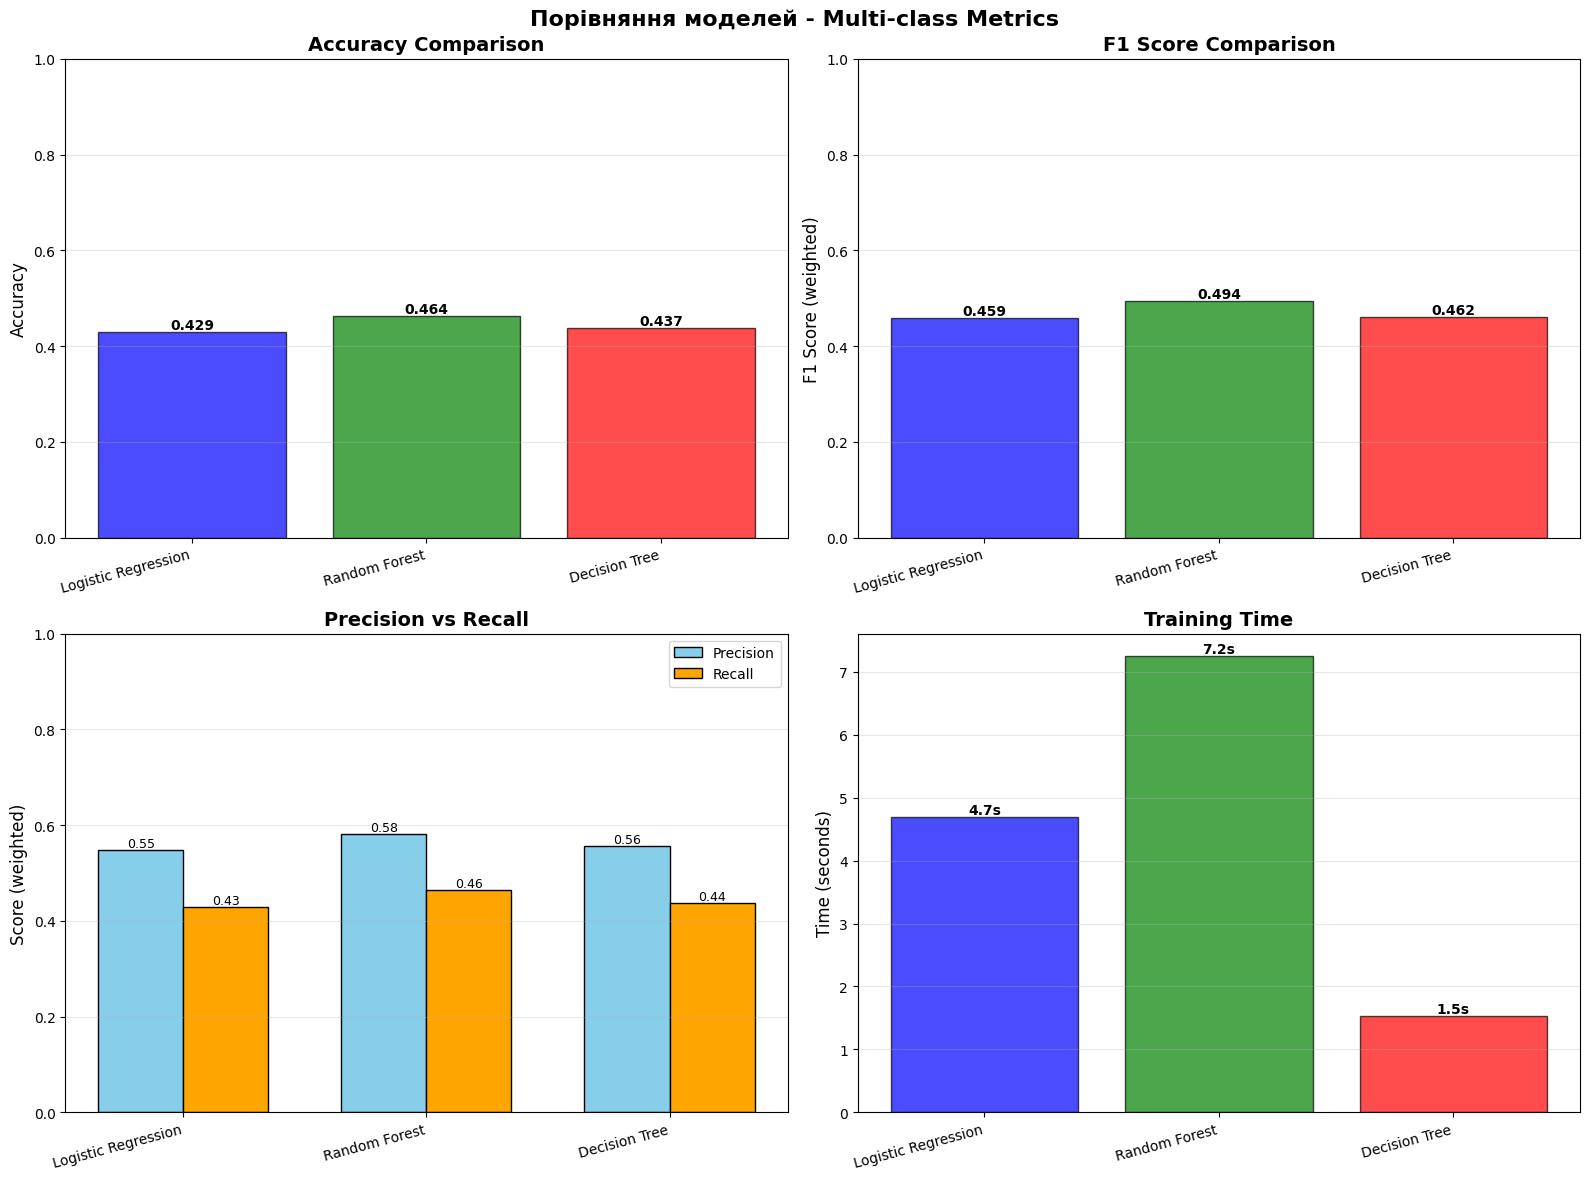

✅ Візуалізацію збережено: visualizations/metrics_comparison.png


In [38]:
# Порівняльна таблиця метрик для всіх моделей
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree'],
    'Accuracy': [lr_accuracy, rf_accuracy, dt_accuracy],
    'F1 Score': [lr_f1, rf_f1, dt_f1],
    'Precision': [lr_precision, rf_precision, dt_precision],
    'Recall': [lr_recall, rf_recall, dt_recall],
    'Training Time (s)': [training_time_lr, training_time_rf, training_time_dt]
}

comparison_df = pd.DataFrame(comparison_data)

print("="*80)
print("ПОРІВНЯННЯ ВСІХ МОДЕЛЕЙ")
print("="*80)
print(comparison_df.to_string(index=False))

# Знаходимо найкращу модель
best_idx = comparison_df['Accuracy'].idxmax()
best_model = comparison_df.loc[best_idx, 'Model']
best_acc = comparison_df.loc[best_idx, 'Accuracy']

print(f"\n🏆 НАЙКРАЩА МОДЕЛЬ: {best_model}")
print(f"   Accuracy: {best_acc:.4f}")

# Візуалізація порівняння метрик
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Порівняння моделей - Multi-class Metrics', fontsize=16, fontweight='bold')

colors_map = {'Logistic Regression': 'blue', 'Random Forest': 'green', 'Decision Tree': 'red'}

# 1. Accuracy Comparison
ax1 = axes[0, 0]
bars = ax1.bar(comparison_df['Model'], comparison_df['Accuracy'], 
               color=[colors_map[m] for m in comparison_df['Model']], alpha=0.7, edgecolor='black')
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 1.0])
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
plt.sca(ax1)
plt.xticks(rotation=15, ha='right')

# 2. F1 Score
ax2 = axes[0, 1]
bars = ax2.bar(comparison_df['Model'], comparison_df['F1 Score'],
               color=[colors_map[m] for m in comparison_df['Model']], alpha=0.7, edgecolor='black')
ax2.set_ylabel('F1 Score (weighted)', fontsize=12)
ax2.set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1.0])
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
plt.sca(ax2)
plt.xticks(rotation=15, ha='right')

# 3. Precision vs Recall
ax3 = axes[1, 0]
x = np.arange(len(comparison_df))
width = 0.35
bars1 = ax3.bar(x - width/2, comparison_df['Precision'], width, 
                label='Precision', color='skyblue', edgecolor='black')
bars2 = ax3.bar(x + width/2, comparison_df['Recall'], width,
                label='Recall', color='orange', edgecolor='black')
ax3.set_ylabel('Score (weighted)', fontsize=12)
ax3.set_title('Precision vs Recall', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax3.legend()
ax3.set_ylim([0, 1.0])
ax3.grid(True, alpha=0.3, axis='y')
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=9)

# 4. Training Time
ax4 = axes[1, 1]
bars = ax4.bar(comparison_df['Model'], comparison_df['Training Time (s)'],
               color=[colors_map[m] for m in comparison_df['Model']], alpha=0.7, edgecolor='black')
ax4.set_ylabel('Time (seconds)', fontsize=12)
ax4.set_title('Training Time', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}s',
             ha='center', va='bottom', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
plt.sca(ax4)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()
plt.savefig('/app/visualizations/metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Візуалізацію збережено: visualizations/metrics_comparison.png")


TOP 10 НАЙВАЖЛИВІШИХ ОЗНАК
               Feature  RF_Importance  DT_Importance
             is_Horror       0.127100       0.202254
        runtimeMinutes       0.121564       0.208734
       runtime_squared       0.107920       0.000000
        is_Documentary       0.107028       0.032539
      production_scale       0.101738       0.075137
            num_actors       0.099847       0.168641
num_countries_released       0.075418       0.078096
              is_Drama       0.066422       0.062598
         is_country_IN       0.036258       0.022977
             startYear       0.035399       0.056225


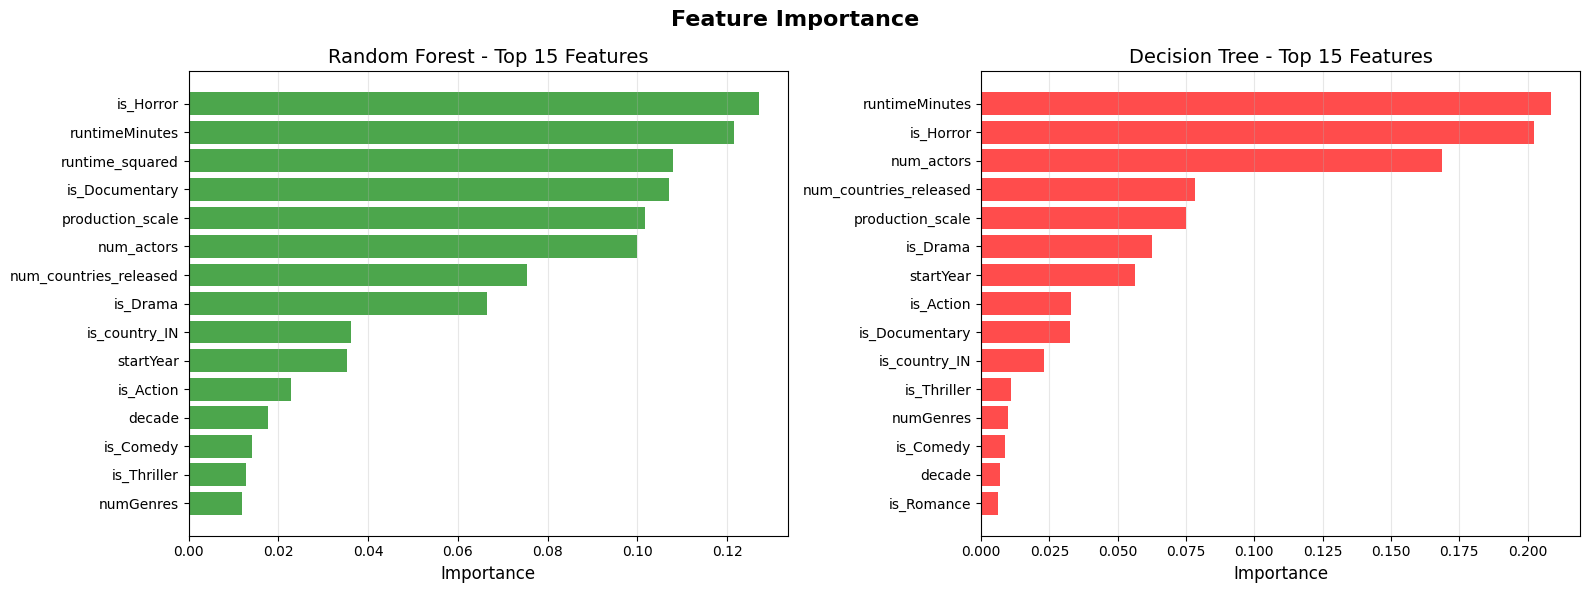


✅ Візуалізацію збережено: visualizations/feature_importance.png


In [39]:
# Feature Importance з Random Forest та Decision Tree
rf_importances = rf_model.featureImportances.toArray()
dt_importances = dt_model.featureImportances.toArray()

# Створюємо DataFrame для зручного відображення
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'RF_Importance': rf_importances,
    'DT_Importance': dt_importances
}).sort_values('RF_Importance', ascending=False)

print("="*80)
print("TOP 10 НАЙВАЖЛИВІШИХ ОЗНАК")
print("="*80)
print(importance_df.head(10).to_string(index=False))

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance', fontsize=16, fontweight='bold')

# Random Forest
ax1 = axes[0]
top_15_rf = importance_df.nlargest(15, 'RF_Importance')
ax1.barh(range(len(top_15_rf)), top_15_rf['RF_Importance'], color='green', alpha=0.7)
ax1.set_yticks(range(len(top_15_rf)))
ax1.set_yticklabels(top_15_rf['Feature'])
ax1.set_xlabel('Importance', fontsize=12)
ax1.set_title('Random Forest - Top 15 Features', fontsize=14)
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Decision Tree
ax2 = axes[1]
top_15_dt = importance_df.nlargest(15, 'DT_Importance')
ax2.barh(range(len(top_15_dt)), top_15_dt['DT_Importance'], color='red', alpha=0.7)
ax2.set_yticks(range(len(top_15_dt)))
ax2.set_yticklabels(top_15_dt['Feature'])
ax2.set_xlabel('Importance', fontsize=12)
ax2.set_title('Decision Tree - Top 15 Features', fontsize=14)
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/app/visualizations/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Візуалізацію збережено: visualizations/feature_importance.png")


### 7.4 Per-Class Performance Analysis


PER-CLASS PERFORMANCE ANALYSIS

📊 Precision по класах:
Class           Average      Good  Masterpiece      Poor
Model                                                   
Decision Tree  0.544327  0.653537     0.105488  0.269451
Logistic Reg   0.540057  0.637418     0.090447  0.286332
Random Forest  0.549180  0.693096     0.111230  0.314918

📊 Recall по класах:
Class           Average      Good  Masterpiece      Poor
Model                                                   
Decision Tree  0.291421  0.491140     0.655477  0.686255
Logistic Reg   0.332624  0.450169     0.628975  0.643031
Random Forest  0.419537  0.443204     0.734982  0.656144

📊 F1-Score по класах:
Class           Average      Good  Masterpiece      Poor
Model                                                   
Decision Tree  0.379608  0.560819     0.181729  0.386964
Logistic Reg   0.411687  0.527674     0.158152  0.396229
Random Forest  0.475683  0.540672     0.193219  0.425579


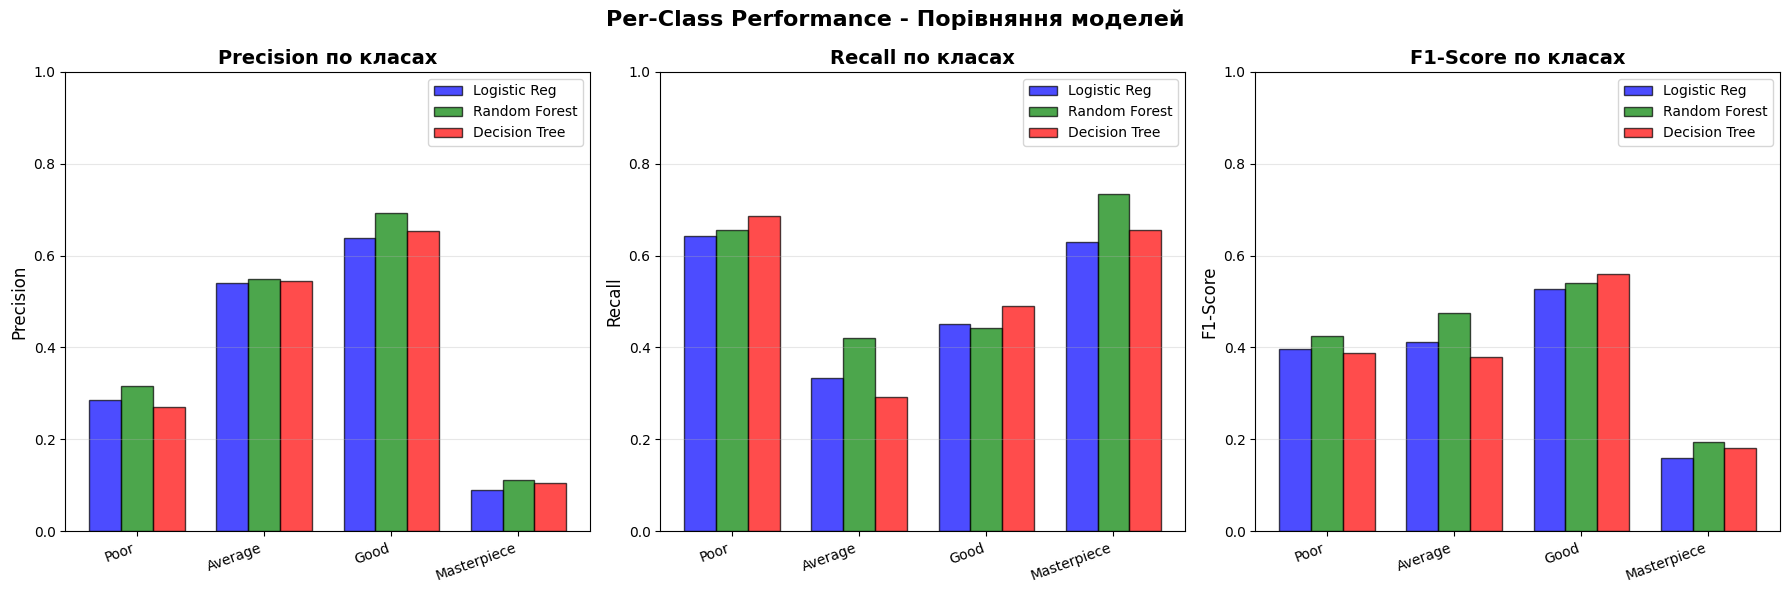


✅ Візуалізацію збережено: visualizations/per_class_performance.png

АНАЛІЗ СКЛАДНОСТІ КЛАСІВ

Найкращий F1-Score для кожного класу:


TypeError: unsupported format string passed to Series.__format__

In [41]:
# Аналіз performance по кожному класу окремо
print("="*80)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*80)

# Функція для обчислення per-class metrics з confusion matrix
def calculate_per_class_metrics(cm_data):
    metrics = []
    for i in range(4):
        tp = cm_data[i][i]
        fp = sum([cm_data[j][i] for j in range(4)]) - tp
        fn = sum(cm_data[i]) - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        support = tp + fn
        
        metrics.append({
            'Class': class_names[i],
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'Support': support
        })
    return pd.DataFrame(metrics)

# Обчислюємо для кожної моделі
lr_per_class = calculate_per_class_metrics(cm_data)
lr_per_class['Model'] = 'Logistic Reg'

rf_per_class = calculate_per_class_metrics(cm_rf_data)
rf_per_class['Model'] = 'Random Forest'

dt_per_class = calculate_per_class_metrics(cm_dt_data)
dt_per_class['Model'] = 'Decision Tree'

# Об'єднуємо
all_per_class = pd.concat([lr_per_class, rf_per_class, dt_per_class])

print("\n📊 Precision по класах:")
pivot_precision = all_per_class.pivot(index='Model', columns='Class', values='Precision')
print(pivot_precision.to_string())

print("\n📊 Recall по класах:")
pivot_recall = all_per_class.pivot(index='Model', columns='Class', values='Recall')
print(pivot_recall.to_string())

print("\n📊 F1-Score по класах:")
pivot_f1 = all_per_class.pivot(index='Model', columns='Class', values='F1')
print(pivot_f1.to_string())

# Візуалізація per-class performance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Per-Class Performance - Порівняння моделей', fontsize=16, fontweight='bold')

models_list = ['Logistic Reg', 'Random Forest', 'Decision Tree']
colors = ['blue', 'green', 'red']

# 1. Precision по класах
ax1 = axes[0]
x = np.arange(len(class_names))
width = 0.25
for i, model in enumerate(models_list):
    model_data = all_per_class[all_per_class['Model'] == model]
    ax1.bar(x + i*width, model_data['Precision'].values, width, 
            label=model, color=colors[i], alpha=0.7, edgecolor='black')
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision по класах', fontsize=14, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(class_names, rotation=20, ha='right')
ax1.legend()
ax1.set_ylim([0, 1.0])
ax1.grid(True, alpha=0.3, axis='y')

# 2. Recall по класах
ax2 = axes[1]
for i, model in enumerate(models_list):
    model_data = all_per_class[all_per_class['Model'] == model]
    ax2.bar(x + i*width, model_data['Recall'].values, width, 
            label=model, color=colors[i], alpha=0.7, edgecolor='black')
ax2.set_ylabel('Recall', fontsize=12)
ax2.set_title('Recall по класах', fontsize=14, fontweight='bold')
ax2.set_xticks(x + width)
ax2.set_xticklabels(class_names, rotation=20, ha='right')
ax2.legend()
ax2.set_ylim([0, 1.0])
ax2.grid(True, alpha=0.3, axis='y')

# 3. F1-Score по класах
ax3 = axes[2]
for i, model in enumerate(models_list):
    model_data = all_per_class[all_per_class['Model'] == model]
    ax3.bar(x + i*width, model_data['F1'].values, width, 
            label=model, color=colors[i], alpha=0.7, edgecolor='black')
ax3.set_ylabel('F1-Score', fontsize=12)
ax3.set_title('F1-Score по класах', fontsize=14, fontweight='bold')
ax3.set_xticks(x + width)
ax3.set_xticklabels(class_names, rotation=20, ha='right')
ax3.legend()
ax3.set_ylim([0, 1.0])
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/app/visualizations/per_class_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Візуалізацію збережено: visualizations/per_class_performance.png")

# Аналіз - які класи найважче передбачити
print("\n" + "="*80)
print("АНАЛІЗ СКЛАДНОСТІ КЛАСІВ")
print("="*80)

# Яка модель найкраща для кожного класу окремо?
print("\nНайкращий F1-Score для кожного класу:")
for class_name in class_names:
    class_data = all_per_class[all_per_class['Class'] == class_name]
    best_model = class_data.loc[class_data['F1'].idxmax(), 'Model']
    best_f1 = class_data['F1'].max()
    emoji = {'Poor': '💩', 'Average': '😐', 'Good': '👍', 'Masterpiece': '🏆'}[class_name]
    print(f"  {emoji} {class_name:12}: {best_model:15} (F1 = {best_f1:.3f})")

# Середній F1 по всіх класах для кожної моделі
print("\nСередній F1-Score (macro-average):")
for model in models_list:
    model_data = all_per_class[all_per_class['Model'] == model]
    avg_f1 = model_data['F1'].mean()
    print(f"  {model:15}: {avg_f1:.4f}")

print("\n💡 Висновки:")
print("   - Краща модель загалом обирається за weighted F1 (враховує розміри класів)")
print("   - Для конкретних класів можуть бути кращими різні моделі")
print("   - Класи з меншою кількістю зразків зазвичай мають нижчі метрики")
